# Leaf PCA reconstruction on optical digits
Fit a KeRF-weighted sparse leaf embedding, compress it to 2D, infer one reconstructed leaf per tree, and decode those leaves back to 8×8 images.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml, load_digits
from sklearn.model_selection import train_test_split

ROOT = Path.cwd().parent if Path.cwd().name in {"demos", "experiments_ae"} else Path.cwd()
sys.path[:0] = [str(ROOT / "src"), str(ROOT / "experiments_ae")]
from leaf_pca import reconstruct_leaf_pca
from mcr import decode_knn
from rfae_binh import encode, predict_encode


In [2]:
# Choose built-in 8×8 optical digits, or cached/downloaded 16×16 USPS.
DATASET = "digits"  # change to "usps"
if DATASET == "digits":
    X, y, image_shape = *load_digits(return_X_y=True), (8, 8)
elif DATASET == "usps":
    X, y = fetch_openml("usps", version=2, return_X_y=True, as_frame=False)
    y, image_shape = y.astype(int) % 10, (16, 16)  # USPS encodes zero as class 10.
else:
    raise ValueError("DATASET must be 'digits' or 'usps'")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0
)

# Fit the extracted 2D KeRF Leaf PCA reconstruction pipeline.
leaf_pca = reconstruct_leaf_pca(X_train, y_train, X_test, image_shape)
rf, Z_train, Z_test = leaf_pca.forest, leaf_pca.Z_train, leaf_pca.Z_test
X_test_hat = leaf_pca.X_test_hat


In [3]:
# Binh RFAE baseline: 2D RF diffusion map plus its KNN/MCR decoder.
rfae = encode(rf, X_train, k=2, stepsize=1)
Z_test_rfae = predict_encode(rfae, rf, X_test)
prep = {"onehot_encoder": None, "ordinal_encoder": None, "to_categorical": []}
np.random.seed(0)
X_test_hat_rfae = decode_knn(
    rf, rfae, Z_test_rfae, preprocessing_meta=prep, k=5, round_vals=False, n_jobs=1
)["x_hat"].to_numpy().reshape(-1, *image_shape)


,mean MSE,median MSE
Leaf PCA,21.497997,21.639564
RFAE (Binh),12.755908,10.428979


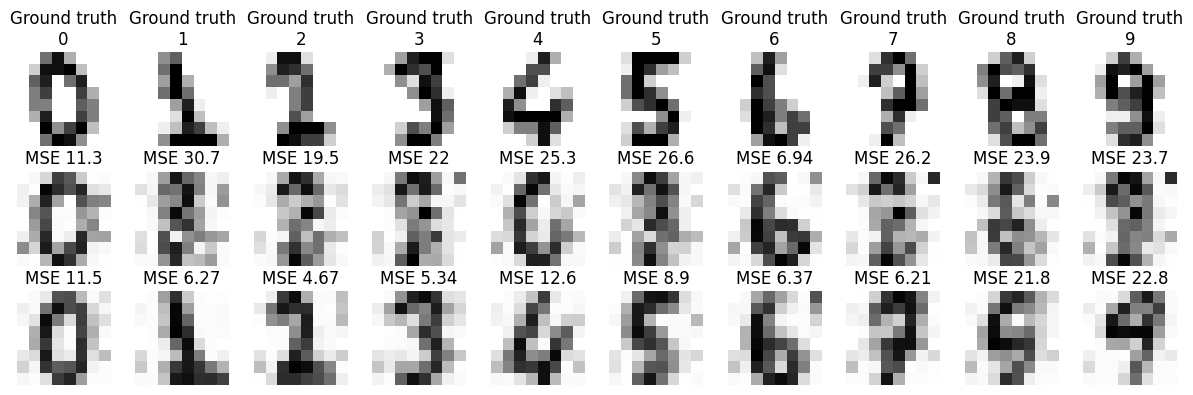

In [4]:
# Compare reconstruction error and one test example per ground-truth class.
mse_leaf = np.mean((X_test - X_test_hat.reshape(len(X_test), -1)) ** 2, axis=1)
mse_rfae = np.mean((X_test - X_test_hat_rfae.reshape(len(X_test), -1)) ** 2, axis=1)
display(pd.DataFrame({
    "mean MSE": [mse_leaf.mean(), mse_rfae.mean()],
    "median MSE": [np.median(mse_leaf), np.median(mse_rfae)],
}, index=["Leaf PCA", "RFAE (Binh)"]))

by_class = [np.flatnonzero(y_test == label)[0] for label in np.sort(np.unique(y_test))]
fig, axes = plt.subplots(3, 10, figsize=(12, 4))
for col, i in enumerate(by_class):
    for row, image in enumerate((X_test[i].reshape(image_shape), X_test_hat[i], X_test_hat_rfae[i])):
        axes[row, col].imshow(image, cmap="gray_r", vmin=X.min(), vmax=X.max())
        axes[row, col].axis("off")
    axes[0, col].set_title(f"Ground truth\n{y_test[i]}")
    axes[1, col].set_title(f"MSE {mse_leaf[i]:.3g}")
    axes[2, col].set_title(f"MSE {mse_rfae[i]:.3g}")
for row, label in enumerate(("ground truth", "Leaf PCA", "RFAE")):
    axes[row, 0].set_ylabel(label)
plt.tight_layout()


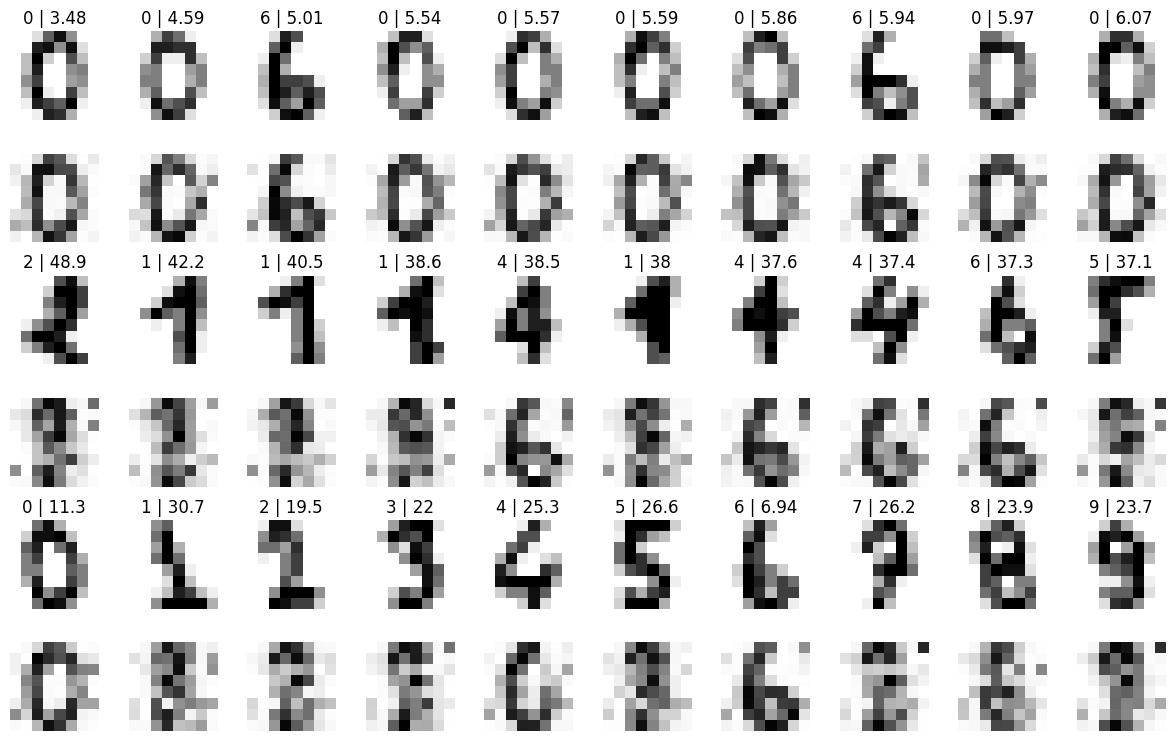

In [5]:
# Rank reconstructions by per-image mean squared pixel error.
mse = np.mean((X_test - X_test_hat.reshape(len(X_test), -1)) ** 2, axis=1)
best, worst = np.argsort(mse)[:10], np.argsort(mse)[-10:][::-1]
by_class = [np.flatnonzero(y_test == label)[0] for label in np.sort(np.unique(y_test))]
fig, axes = plt.subplots(6, 10, figsize=(12, 7.5))
for col, (best_i, worst_i) in enumerate(zip(best, worst)):
    for row, i in enumerate((best_i, best_i, worst_i, worst_i)):
        image = X_test[i].reshape(image_shape) if row % 2 == 0 else X_test_hat[i]
        axes[row, col].imshow(image, cmap="gray_r", vmin=X.min(), vmax=X.max())
        axes[row, col].axis("off")
    axes[0, col].set_title(f"{y_test[best_i]} | {mse[best_i]:.3g}")
    axes[2, col].set_title(f"{y_test[worst_i]} | {mse[worst_i]:.3g}")
for col, i in enumerate(by_class):
    axes[4, col].imshow(X_test[i].reshape(image_shape), cmap="gray_r", vmin=X.min(), vmax=X.max())
    axes[5, col].imshow(X_test_hat[i], cmap="gray_r", vmin=X.min(), vmax=X.max())
    axes[4, col].set_title(f"{y_test[i]} | {mse[i]:.3g}")
    axes[4, col].axis("off"); axes[5, col].axis("off")
for row, label in enumerate(("best original", "best decoded", "worst original", "worst decoded", "class original", "class decoded")):
    axes[row, 0].set_ylabel(label)
plt.tight_layout()
